In [1]:
import networkx as nx
%pip install python-louvain
import community as community_louvain
import numpy as np
import locale
import time

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for python-louvain: filename=python_louvain-0.16-py3-none-any.whl size=9460 sha256=9b8cc55a5558f986035c9affc2376804bd5872b2fc701e6e3311b26c79bc2e13
  Stored in directory: /home/karen/.cache/pip/wheels/40/f1/e3/485b698c520fa0baee1d07897abc7b8d6479b7d199ce96f4af
Successfully built python-louvain

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: /home/karen/envs/udes_sd_a25/bin/python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


### Création du graphe à partir du fichier `edgelist`

In [2]:
G = nx.read_edgelist("youtube.graph.edgelist", nodetype=int)

In [3]:
N = G.number_of_nodes()
m = G.number_of_edges()
nb_composantes = nx.number_connected_components(G)

In [4]:
print(f"nombre de nœuds : {N}")
print(f"nombre d’arêtes : {m}")
print(f"nombre de composantes connexes : {nb_composantes}")
print(f"voisins du nœud 1 : {list(G.neighbors(11))}")

nombre de nœuds : 22754
nombre d’arêtes : 65601
nombre de composantes connexes : 1
voisins du nœud 1 : [165, 349, 718, 727, 743, 905, 908, 1042, 1073, 1119, 3491, 3493, 3511, 3517, 3518, 3519, 3533, 3535, 3540, 3542, 3546, 3548, 3558, 3559, 3562, 5109, 13568, 655575, 663545, 665658, 665659, 1085697]


### Budget idéal et couverture idéale

In [5]:
def ideal_budget_and_coverage(N, C_0=200):
    return C_0*N, 1

In [6]:
C_0 = 200
ideal_budget, ideal_coverage = ideal_budget_and_coverage(N, C_0)
print(f"budget idéal = {ideal_budget:,.2f} CAD et couverture idéale = {ideal_coverage:.0%}")

budget idéal = 4,550,800.00 CAD et couverture idéale = 100%


### Détection des communautés à l’aide de l’algorithme de Louvain.

In [7]:
def get_communities(G, algo="louvain"):
    communities = {}
    if algo=="louvain":
        partition = community_louvain.best_partition(G)
        for node, comm in partition.items():
            communities.setdefault(comm, []).append(node)
    else:
        lpa_communities = nx.algorithms.community.label_propagation_communities(G)
        lpa_result = [list(c) for c in lpa_communities]
        for i, comm in enumerate(lpa_communities):
            communities[i] = list(comm)   
    return communities

In [8]:
communities_lpa = get_communities(G, algo="lpa")
print("nombre total de communautés détectées :", len(communities_lpa))

nombre total de communautés détectées : 1319


In [9]:
communities_louvain = get_communities(G, algo="louvain")
print("nombre total de communautés détectées :", len(communities_louvain))

nombre total de communautés détectées : 34


### Détermination d’un·e influenceur·euse par communauté, choisi·e selon la centralité de proximité

In [10]:
def get_community_and_profiles(G, communities, influence="closeness"):
    com_and_profiles = {}
    for comm_id, nodes in communities.items():
        community = G.subgraph(nodes)
        if influence=="closeness":
            closeness = nx.closeness_centrality(community)
            influencer = max(closeness, key=closeness.get)
        elif influence=="degree":
            degree = nx.degree_centrality(community)
            influencer = max(degree, key=degree.get)
        elif influence=="betweenness":
            betweenness = nx.betweenness_centrality(community)
            influencer = max(betweenness, key=betweenness.get)
        else:
            influencer = np.random.choice(list(nodes))
        profile = {"community":community, "influencer": influencer}
        com_and_profiles[comm_id]=profile
    return com_and_profiles 

In [11]:
com_and_profiles_louvain = get_community_and_profiles(G, communities_louvain, influence="closeness")

In [12]:
com_and_profiles_lpa = get_community_and_profiles(G, communities_lpa, influence="random")

###  Simulation du budget et de la couverture obtenue par propagation de l’influence

In [13]:
def get_budget_coverage_per_community(com_and_profile, N, eta = 2, C_1=20, C_2=1000):
    community = com_and_profile['community']
    influencer = com_and_profile['influencer']
    counter = 1
    temps_propagation = 0
    for node in community.nodes():
        if node != influencer:
            prob = np.random.uniform(0.8, 1)
            choice = np.random.choice([0, 1], p=[1-prob, prob])
            if choice == 1:
                try:
                    distance = nx.shortest_path_length(community, source=influencer, target=node)
                    counter +=1
                    temps_propagation += distance
                except Exception as e:
                    continue
                
    budget = C_2 + (counter-1)*C_1
    temps_propagation *= eta
    coverage = counter/N
    return budget, coverage, temps_propagation

In [14]:
def get_budget_and_coverage(com_and_profiles, eta=2, C_1=20, C_2=1000):
    total_budget, total_coverage, total_temps_propagation = 0, 0, 0
    for comm_id in com_and_profiles:
        com_and_profile = com_and_profiles[comm_id]
        budget, coverage, temps_propagation = get_budget_coverage_per_community(com_and_profile, N, eta, C_1, C_2)
        total_budget +=budget
        total_coverage +=coverage
        total_temps_propagation +=temps_propagation
    return total_budget, total_coverage, total_temps_propagation

In [15]:
eta, C_1, C_2 =2, 20, 1000

In [16]:
sim_budget, sim_coverage, sim_temps_propagation = get_budget_and_coverage(com_and_profiles_louvain, eta, C_1, C_2)
print(f"budget simulé = {sim_budget:,.2f} CAD, couverture simulée = {sim_coverage:.0%} et temps de propagation = {sim_temps_propagation:,.2f} sec ")

budget simulé = 442,360.00 CAD, couverture simulée = 90% et temps de propagation = 93,566.00 sec 


In [17]:
sim_budget, sim_coverage, sim_temps_propagation = get_budget_and_coverage(com_and_profiles_lpa, eta, C_1, C_2)
print(f"budget simulé = {sim_budget:,.2f} CAD, couverture simulée = {sim_coverage:.0%} et temps de propagation = {sim_temps_propagation:,.2f} sec ")

budget simulé = 1,704,560.00 CAD, couverture simulée = 91% et temps de propagation = 149,512.00 sec 


### Comparez les différents résultats obtenus

Comparez les différents résultats obtenus selon la méthode de détection des communautés et l’approche de détermination des nœuds influenceurs, 
      en termes de budget simulé, de couverture simulée, de temps total de propagation et de temps d’exécution. Proposez des visualisations pertinentes afin de faciliter la comparaison des résultats, notamment en termes de couverture perdue et de montant d’argent épargné par approche.

#### 2.2 Minimisation de couts de propagande simulée

In [18]:
scenarios = []
influence_methods = ["closeness", "degree", "betweenness", "random"]  # def get_community_and_profiles(G, communities, influence="closeness")


In [19]:
# --- Simulation de la propagation de l'influence avec noeud-influenceur Louvain ---- 
print(f"budget idéal = {ideal_budget:,.2f} CAD et couverture idéale = {ideal_coverage:.0%}")


# Étape 2 différent centralité (proximité, degré, intermédiarité, aléatoire par la liste influence_methods et la fonction get_community_and_profiles)
for influence in influence_methods:
    print(f"\n=== Algo communautés: Louvain | influenceur: {influence} ===")
    t0 = time.time()
    com_and_profiles = get_community_and_profiles(G, communities_louvain, influence)
    sim_budget, sim_coverage, sim_temps_propagation = get_budget_and_coverage(com_and_profiles, eta, C_1,C_2)
    exec_time = time.time() - t0

    # Étape 3 les métriques
    print(f"Budget simulé = {sim_budget:,.2f} CAD")
    print(f"Couverture simulée = {sim_coverage:.2%}")
    print(f"Temps propagation = {sim_temps_propagation:,.2f} sec")
    print(f"Temps d'exécution = {exec_time:,.2f} sec")
    
    scenarios.append({
        "algo_communautes": "Louvain",
        "influence": influence,
        "budget": sim_budget,
        "couverture": sim_coverage,
        "temps_propagation": sim_temps_propagation,
        "temps_execution": exec_time,
        "couverture_perdue": 1 - sim_coverage,
        "argent_epargne": ideal_budget - sim_budget,
    })


budget idéal = 4,550,800.00 CAD et couverture idéale = 100%

=== Algo communautés: Louvain | influenceur: closeness ===
Budget simulé = 443,240.00 CAD
Couverture simulée = 90.08%
Temps propagation = 93,860.00 sec
Temps d'exécution = 337.95 sec

=== Algo communautés: Louvain | influenceur: degree ===
Budget simulé = 443,620.00 CAD
Couverture simulée = 90.16%
Temps propagation = 95,100.00 sec
Temps d'exécution = 8.46 sec

=== Algo communautés: Louvain | influenceur: betweenness ===
Budget simulé = 443,420.00 CAD
Couverture simulée = 90.12%
Temps propagation = 94,094.00 sec
Temps d'exécution = 515.07 sec

=== Algo communautés: Louvain | influenceur: random ===
Budget simulé = 442,180.00 CAD
Couverture simulée = 89.84%
Temps propagation = 157,480.00 sec
Temps d'exécution = 5.24 sec


Le choix aléatoire des influenceurs maintient une couverture similaire mais rallonge nettement le temps de propagation de l’information. Ce qui est logique vu que le choix de l'influenceur dans la communauté n'est pas placé de facon optimisé. Cela montre l'intérêt d'utiliser une centralité plutôt qu'un choix au hasard

In [20]:
# --- EXPÉRIMENTES LPA SEULEMENT ---
print(f"budget idéal = {ideal_budget:,.2f} CAD et couverture idéale = {ideal_coverage:.0%}")
influence_methods = [ "random", "degree"]  # , "closeness", "betweenness" prennent trop de temps
for influence in influence_methods:
    print(f"\n=== Algo communautés: LPA | influenceur: {influence} ===")
    t0 = time.time()
    
    com_and_profiles = get_community_and_profiles(G,communities_lpa,influence=influence)
    sim_budget, sim_coverage, sim_temps_propagation = get_budget_and_coverage(com_and_profiles, eta, C_1, C_2)
    exec_time = time.time() - t0
    
    print(f"Budget simulé = {sim_budget:,.2f} CAD")
    print(f"Couverture simulée = {sim_coverage:.2%}")
    print(f"Temps propagation = {sim_temps_propagation:,.2f} sec")
    print(f"Temps d'exécution = {exec_time:,.2f} sec")
    
    scenarios.append({
        "algo_communautes": "LPA",
        "influence": influence,
        "budget": sim_budget,
        "couverture": sim_coverage,
        "temps_propagation": sim_temps_propagation,
        "temps_execution": exec_time,
        "couverture_perdue": 1 - sim_coverage,
        "argent_epargné": ideal_budget - sim_budget,
    })


budget idéal = 4,550,800.00 CAD et couverture idéale = 100%

=== Algo communautés: LPA | influenceur: random ===
Budget simulé = 1,704,420.00 CAD
Couverture simulée = 90.49%
Temps propagation = 124,252.00 sec
Temps d'exécution = 3.09 sec

=== Algo communautés: LPA | influenceur: degree ===
Budget simulé = 1,705,040.00 CAD
Couverture simulée = 90.63%
Temps propagation = 86,350.00 sec
Temps d'exécution = 21.22 sec


Dans le cas de LPA, l’algorithme détecte 1319 communautés, contre seulement 32 pour Louvain. Ainsi les centralité comme closeness ou betweenness sur chaque communauté LPA devient alors très long en pratique.

Pour cette raison, nous avons limité les expériences LPA aux stratégies de centralité les plus légères (degré et choix aléatoire). Pour Louvain, en revanche, nous avons pu tester les quatre stratégies (closeness, degré, betweenness et aléatoire), car le nombre de communautés est beaucoup plus faible (32), ce qui rend le calcul des centralités plus abordable.

  algo_communautes    influence   budget  couverture  temps_propagation  \
0          Louvain    closeness   443240    0.900765              93860   
1          Louvain       degree   443620    0.901600              95100   
2          Louvain  betweenness   443420    0.901160              94094   
3          Louvain       random   442180    0.898435             157480   
4              LPA       random  1704420    0.904896             124252   
5              LPA       degree  1705040    0.906258              86350   

   temps_execution  couverture_perdue  argent_epargne  argent_epargné  
0       337.950179           0.099235       4107560.0             NaN  
1         8.457297           0.098400       4107180.0             NaN  
2       515.070517           0.098840       4107380.0             NaN  
3         5.235710           0.101565       4108620.0             NaN  
4         3.086022           0.095104             NaN       2846380.0  
5        21.215639           0.093742     

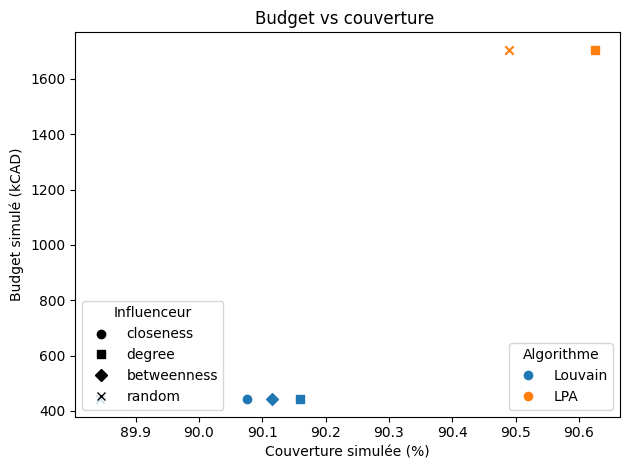

In [21]:
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.lines import Line2D

df_results = pd.DataFrame(scenarios)
print(df_results)
df_results["scenario"] = df_results["algo_communautes"] + " + " + df_results["influence"]
plt.figure()
markers = {
    "closeness": "o",
    "degree": "s",
    "betweenness": "D",
    "random": "x"
}
colors = {
    "Louvain": "C0",
    "LPA": "C1"
}
for _, row in df_results.iterrows():
    plt.scatter(
        row["couverture"] * 100,     # en %
        row["budget"] / 1000,        # en k$
        marker=markers.get(row["influence"], "o"),
        color=colors.get(row["algo_communautes"], "C0"),
        label=row["scenario"]  # on va gérer la légende après
    )

plt.xlabel("Couverture simulée (%)")
plt.ylabel("Budget simulé (kCAD)")
plt.title("Budget vs couverture ")

legend_algo = [
    Line2D([0], [0], marker="o", color="w", label="Louvain", markerfacecolor="C0", markersize=8),
    Line2D([0], [0], marker="o", color="w", label="LPA", markerfacecolor="C1", markersize=8),
]
legend_influence = [
    Line2D([0], [0], marker="o", color="k", label="closeness", linestyle=""),
    Line2D([0], [0], marker="s", color="k", label="degree", linestyle=""),
    Line2D([0], [0], marker="D", color="k", label="betweenness", linestyle=""),
    Line2D([0], [0], marker="x", color="k", label="random", linestyle=""),
]
first_legend = plt.legend(handles=legend_algo, title="Algorithme", loc="lower right")
plt.gca().add_artist(first_legend)
plt.legend(handles=legend_influence, title="Influenceur", loc="lower left")
plt.tight_layout()
plt.show()


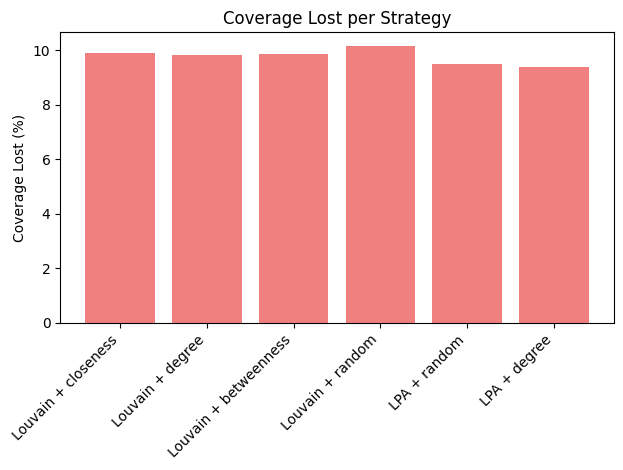

In [32]:
# === Coverage Lost per Strategy ===
plt.figure()
plt.bar(
    df_results["scenario"],
    df_results["couverture_perdue"] * 100,  # convert to %
    color="lightcoral"
)

plt.title("Coverage Lost per Strategy")
plt.ylabel("Coverage Lost (%)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


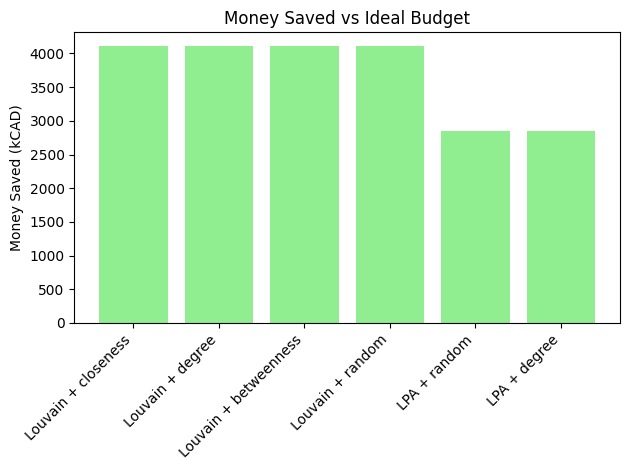

In [28]:
# Normalize the column name across all rows
df_results["argent_epargne_final"] = df_results["argent_epargne"].fillna(
    df_results["argent_epargné"]
)

# === Money Saved per Strategy ===
plt.figure()
plt.bar(
    df_results["scenario"],
    df_results["argent_epargne_final"] / 1000,  # convert to kCAD
    color="lightgreen"
)

plt.title("Money Saved vs Ideal Budget")
plt.ylabel("Money Saved (kCAD)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


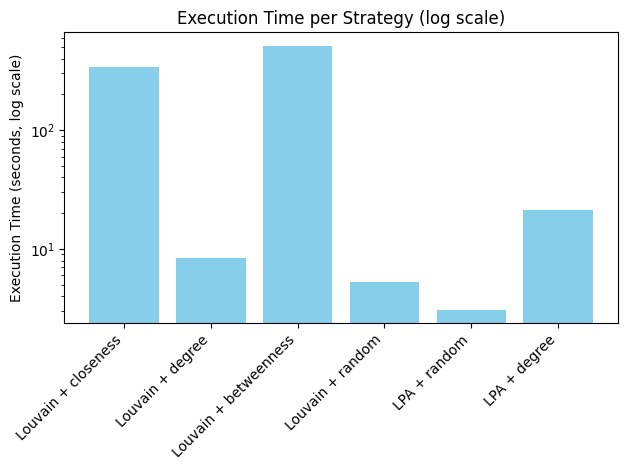

In [29]:
# === Execution Time per Strategy ===
plt.figure()
plt.bar(
    df_results["scenario"],
    df_results["temps_execution"],
    color="skyblue"
)

plt.yscale("log")
plt.title("Execution Time per Strategy (log scale)")
plt.ylabel("Execution Time (seconds, log scale)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


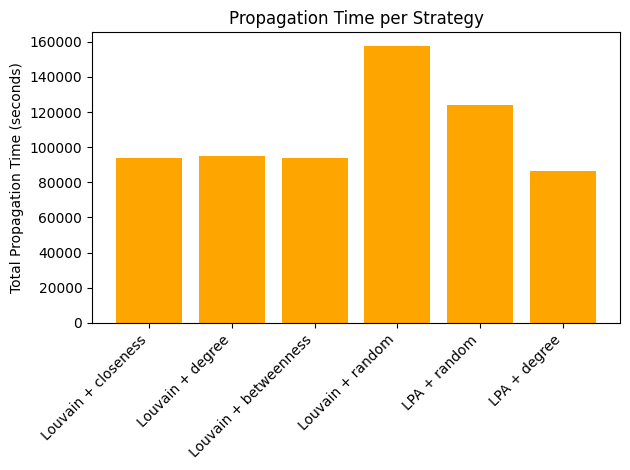

In [30]:
# === Propagation Time per Strategy ===
plt.figure()
plt.bar(
    df_results["scenario"],
    df_results["temps_propagation"],
    color="orange"
)

plt.title("Propagation Time per Strategy")
plt.ylabel("Total Propagation Time (seconds)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()
